## 〽️ McDonald's Menu Item Type Prediction

Given *data about McDonald's menu items*, let's try to predict the **type** of a given item.

We will use a TensorFlow ANN with two inputs to make our predictions.

Data source: https://www.kaggle.com/datasets/mcdonalds/nutrition-facts

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('archive/menu.csv')
data

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,Sodium (% Daily Value),Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,260,87,750,31,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,25,8,770,32,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,45,15,780,33,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,285,95,860,36,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,50,16,880,37,30,10,4,17,2,21,6,0,25,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,Smoothies & Shakes,McFlurry with Oreo Cookies (Small),10.1 oz (285 g),510,150,17.0,26,9.0,44,0.5,45,14,280,12,80,27,1,4,64,12,15,0,40,8
256,Smoothies & Shakes,McFlurry with Oreo Cookies (Medium),13.4 oz (381 g),690,200,23.0,35,12.0,58,1.0,55,19,380,16,106,35,1,5,85,15,20,0,50,10
257,Smoothies & Shakes,McFlurry with Oreo Cookies (Snack),6.7 oz (190 g),340,100,11.0,17,6.0,29,0.0,30,9,190,8,53,18,1,2,43,8,10,0,25,6
258,Smoothies & Shakes,McFlurry with Reese's Peanut Butter Cups (Medium),14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,60,20,400,17,114,38,2,9,103,21,20,0,60,6


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    str    
 1   Item                           260 non-null    str    
 2   Serving Size                   260 non-null    str    
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int64  
 13  S

#### Encoding Label Column

In [4]:
data['Category'].unique()

<StringArray>
[         'Breakfast',        'Beef & Pork',     'Chicken & Fish',
             'Salads',     'Snacks & Sides',           'Desserts',
          'Beverages',       'Coffee & Tea', 'Smoothies & Shakes']
Length: 9, dtype: str

In [5]:
label_encoder = LabelEncoder()

data['Category'] = label_encoder.fit_transform(data['Category'])

label_mappings = dict(enumerate(label_encoder.classes_))

In [6]:
label_mappings

{0: 'Beef & Pork',
 1: 'Beverages',
 2: 'Breakfast',
 3: 'Chicken & Fish',
 4: 'Coffee & Tea',
 5: 'Desserts',
 6: 'Salads',
 7: 'Smoothies & Shakes',
 8: 'Snacks & Sides'}

In [7]:
data

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,Sodium (% Daily Value),Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,2,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,260,87,750,31,31,10,4,17,3,17,10,0,25,15
1,2,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,25,8,770,32,30,10,4,17,3,18,6,0,25,8
2,2,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,45,15,780,33,29,10,4,17,2,14,8,0,25,10
3,2,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,285,95,860,36,30,10,4,17,2,21,15,0,30,15
4,2,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,50,16,880,37,30,10,4,17,2,21,6,0,25,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,7,McFlurry with Oreo Cookies (Small),10.1 oz (285 g),510,150,17.0,26,9.0,44,0.5,45,14,280,12,80,27,1,4,64,12,15,0,40,8
256,7,McFlurry with Oreo Cookies (Medium),13.4 oz (381 g),690,200,23.0,35,12.0,58,1.0,55,19,380,16,106,35,1,5,85,15,20,0,50,10
257,7,McFlurry with Oreo Cookies (Snack),6.7 oz (190 g),340,100,11.0,17,6.0,29,0.0,30,9,190,8,53,18,1,2,43,8,10,0,25,6
258,7,McFlurry with Reese's Peanut Butter Cups (Medium),14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,60,20,400,17,114,38,2,9,103,21,20,0,60,6


#### Encoding Item Column

In [8]:
data['Item']

0                                           Egg McMuffin
1                                      Egg White Delight
2                                       Sausage McMuffin
3                              Sausage McMuffin with Egg
4                       Sausage McMuffin with Egg Whites
                             ...                        
255                   McFlurry with Oreo Cookies (Small)
256                  McFlurry with Oreo Cookies (Medium)
257                   McFlurry with Oreo Cookies (Snack)
258    McFlurry with Reese's Peanut Butter Cups (Medium)
259     McFlurry with Reese's Peanut Butter Cups (Snack)
Name: Item, Length: 260, dtype: str

In [9]:
names = data['Item'].copy()

tokenizer = Tokenizer()
tokenizer.fit_on_texts(names)

names = tokenizer.texts_to_sequences(names)

In [10]:
names

[[8, 52],
 [8, 113, 114],
 [18, 52],
 [18, 52, 2, 8],
 [18, 52, 2, 8, 24],
 [70, 8, 52],
 [14, 8, 19, 6, 20, 6],
 [14, 8, 19, 6, 1, 6],
 [14, 8, 19, 6, 2, 8, 24, 20, 6],
 [14, 8, 19, 6, 2, 8, 24, 1, 6],
 [18, 6, 20, 6],
 [18, 6, 1, 6],
 [18, 6, 2, 8, 20, 6],
 [18, 6, 2, 8, 1, 6],
 [18, 6, 2, 8, 24, 20, 6],
 [18, 6, 2, 8, 24, 1, 6],
 [71, 72, 5, 6, 20, 6],
 [71, 72, 5, 6, 1, 6],
 [70, 8, 6, 20, 6],
 [14, 8, 19, 53],
 [14, 8, 19, 53, 2, 8, 24],
 [18, 53],
 [18, 8, 19, 53],
 [18, 8, 19, 53, 2, 8, 24],
 [14, 8, 19, 73],
 [14, 8, 19, 73, 2, 8, 24],
 [70, 8, 19, 73],
 [30, 37, 20, 6],
 [30, 37, 1, 6],
 [30, 37, 2, 8, 24, 20, 6],
 [30, 37, 2, 8, 24, 1, 6],
 [30, 37, 2, 48, 20, 6],
 [30, 37, 2, 48, 1, 6],
 [30, 37, 2, 48, 74, 8, 24, 20, 6],
 [30, 37, 2, 48, 74, 8, 24, 1, 6],
 [48],
 [48, 74, 18],
 [18, 115],
 [116, 92],
 [117, 118],
 [75, 93, 76],
 [75, 93, 76, 77, 92, 28],
 [30, 119],
 [54, 55, 2, 19],
 [54, 55, 2, 14, 19],
 [54, 55, 2, 14, 120, 25],
 [54, 55, 121],
 [59, 54, 55, 2, 19],
 [12

In [11]:
tokenizer.word_index

{'large': 1,
 'with': 2,
 'medium': 3,
 'small': 4,
 'chicken': 5,
 'biscuit': 6,
 'iced': 7,
 'egg': 8,
 'latte': 9,
 'nonfat': 10,
 'mocha': 11,
 'caramel': 12,
 'french': 13,
 'bacon': 14,
 'vanilla': 15,
 'premium': 16,
 'coffee': 17,
 'sausage': 18,
 'cheese': 19,
 'regular': 20,
 'crispy': 21,
 'chocolate': 22,
 'grilled': 23,
 'whites': 24,
 'ranch': 25,
 'milk': 26,
 'shake': 27,
 'sugar': 28,
 'free': 29,
 'big': 30,
 'sandwich': 31,
 'snack': 32,
 'hazelnut': 33,
 'syrup': 34,
 'frappé': 35,
 'smoothie': 36,
 'breakfast': 37,
 'mcwrap': 38,
 'hot': 39,
 'diet': 40,
 'dr': 41,
 'pepper': 42,
 'tea': 43,
 'mcflurry': 44,
 'salad': 45,
 'strawberry': 46,
 'child': 47,
 'hotcakes': 48,
 'classic': 49,
 'sweet': 50,
 'wrap': 51,
 'mcmuffin': 52,
 'mcgriddles': 53,
 'quarter': 54,
 'pounder': 55,
 'southwest': 56,
 'mcnuggets': 57,
 'piece': 58,
 'double': 59,
 'mcchicken': 60,
 'fries': 61,
 'chip': 62,
 'coca': 63,
 'cola': 64,
 'coke': 65,
 'sprite': 66,
 'minute': 67,
 'maid': 

In [12]:
vocab_length = len(tokenizer.word_index) + 1

max_seq_len = np.max(list(map(lambda x: len(x), names)))

print("Vocabulary Length:", vocab_length)
print("Maximum Sequence Length:", max_seq_len)

Vocabulary Length: 155
Maximum Sequence Length: 9


In [13]:
names = pad_sequences(names, maxlen=max_seq_len, padding='post')
names

array([[  8,  52,   0, ...,   0,   0,   0],
       [  8, 113, 114, ...,   0,   0,   0],
       [ 18,  52,   0, ...,   0,   0,   0],
       ...,
       [ 44,   2,  90, ...,   0,   0,   0],
       [ 44,   2, 109, ...,   3,   0,   0],
       [ 44,   2, 109, ...,  32,   0,   0]], shape=(260, 9), dtype=int32)

In [14]:
data = data.drop('Item', axis=1)
data

,Category,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,Sodium (% Daily Value),Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,2,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,260,87,750,31,31,10,4,17,3,17,10,0,25,15
1,2,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,25,8,770,32,30,10,4,17,3,18,6,0,25,8
2,2,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,45,15,780,33,29,10,4,17,2,14,8,0,25,10
3,2,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,285,95,860,36,30,10,4,17,2,21,15,0,30,15
4,2,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,50,16,880,37,30,10,4,17,2,21,6,0,25,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,7,10.1 oz (285 g),510,150,17.0,26,9.0,44,0.5,45,14,280,12,80,27,1,4,64,12,15,0,40,8
256,7,13.4 oz (381 g),690,200,23.0,35,12.0,58,1.0,55,19,380,16,106,35,1,5,85,15,20,0,50,10
257,7,6.7 oz (190 g),340,100,11.0,17,6.0,29,0.0,30,9,190,8,53,18,1,2,43,8,10,0,25,6
258,7,14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,60,20,400,17,114,38,2,9,103,21,20,0,60,6


#### Cleaning Serving Size Feature

In [15]:
data['Serving Size'].unique()

<StringArray>
[  '4.8 oz (136 g)',   '4.8 oz (135 g)',   '3.9 oz (111 g)',
   '5.7 oz (161 g)',   '6.5 oz (185 g)',   '5.3 oz (150 g)',
   '5.8 oz (164 g)',   '5.4 oz (153 g)',   '5.9 oz (167 g)',
   '4.1 oz (117 g)',
 ...
 '6 fl oz (177 ml)',     '22 fl oz cup',       '16.9 fl oz',
     '20 fl oz cup',     '32 fl oz cup',  '16.2 oz (460 g)',
   '7.3 oz (207 g)',  '10.1 oz (285 g)',  '13.4 oz (381 g)',
  '14.2 oz (403 g)']
Length: 107, dtype: str

In [16]:
units = []

def get_grams(serving):
    units.append(0)
    return float(re.search(r'(?<=\()[\d]+', serving).group(0))
    
def get_ml(serving):
    units.append(1)
    return float(re.search(r'(?<=\()[\d]+', serving).group(0))

def get_fl_oz(serving):
    units.append(2)
    return float(re.search(r'^[\d.]+', serving).group(0))

In [17]:
def get_units(serving):
    if ' g)' in serving:
        return get_grams(serving)
    elif ' ml)' in serving:
        return get_ml(serving)
    else: 
        return get_fl_oz(serving)

In [18]:
data['Serving Size'] = data['Serving Size'].apply(get_units)
data['Serving Size']

0      136.0
1      135.0
2      111.0
3      161.0
4      161.0
       ...  
255    285.0
256    381.0
257    190.0
258    403.0
259    202.0
Name: Serving Size, Length: 260, dtype: float64

In [19]:
data['Serving Units'] = units

In [20]:
data

,Category,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,Sodium (% Daily Value),Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value),Serving Units
0,2,136.0,300,120,13.0,20,5.0,25,0.0,260,87,750,31,31,10,4,17,3,17,10,0,25,15,0
1,2,135.0,250,70,8.0,12,3.0,15,0.0,25,8,770,32,30,10,4,17,3,18,6,0,25,8,0
2,2,111.0,370,200,23.0,35,8.0,42,0.0,45,15,780,33,29,10,4,17,2,14,8,0,25,10,0
3,2,161.0,450,250,28.0,43,10.0,52,0.0,285,95,860,36,30,10,4,17,2,21,15,0,30,15,0
4,2,161.0,400,210,23.0,35,8.0,42,0.0,50,16,880,37,30,10,4,17,2,21,6,0,25,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,7,285.0,510,150,17.0,26,9.0,44,0.5,45,14,280,12,80,27,1,4,64,12,15,0,40,8,0
256,7,381.0,690,200,23.0,35,12.0,58,1.0,55,19,380,16,106,35,1,5,85,15,20,0,50,10,0
257,7,190.0,340,100,11.0,17,6.0,29,0.0,30,9,190,8,53,18,1,2,43,8,10,0,25,6,0
258,7,403.0,810,290,32.0,50,15.0,76,1.0,60,20,400,17,114,38,2,9,103,21,20,0,60,6,0


In [21]:
def onehot_encode(df, column, prefix):
    df = df.copy()
    dummies = pd.get_dummies(df[column], prefix=prefix, dtype=int)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(column, axis=1)
    return df

In [22]:
data = onehot_encode(data, 'Serving Units', 'units')

#### Splitting and Scaling

In [23]:
y = data['Category'].copy()
X = data.drop('Category', axis=1).copy()

In [24]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [25]:
names_train, names_test, X_train, X_test, y_train, y_test = train_test_split(names, X, y, train_size=0.7)

### Modeling

In [26]:
num_classes = len(y.unique())
print("Number of classes:", num_classes)

name_feature_length = names.shape[1]
print("Name feature length:", name_feature_length)

other_feature_length = X.shape[1]
print("Other feature length:", other_feature_length)

Number of classes: 9
Name feature length: 9
Other feature length: 25


In [27]:
# Name features
name_input = tf.keras.Input(shape=(name_feature_length,), name='name_input')

name_embedding = tf.keras.layers.Embedding(
    input_dim = vocab_length,
    output_dim = 64,
    input_length = name_feature_length,
    name='name_embedding'
)(name_input)

name_flatten = tf.keras.layers.Flatten(name='name_flatten')(name_embedding)

# Other features
other_input = tf.keras.Input(shape=(other_feature_length,), name='other_input')

dense_1 = tf.keras.layers.Dense(64, activation='relu', name='dense_1')(other_input)
dense_2 = tf.keras.layers.Dense(64, activation='relu', name='dense_2')(dense_1)

# Combined
concat = tf.keras.layers.concatenate([name_flatten, dense_2], name='concatenate')

outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='output_layer')(concat)

# Create model
model = tf.keras.Model(inputs=[name_input, other_input], outputs=outputs)

D:\miniconda3\envs\tfenv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ name_input (InputLayer)       │ (None, 9)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ other_input (InputLayer)      │ (None, 25)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ name_embedding (Embedding)    │ (None, 9, 64)             │           9,920 │ name_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           1,664 │ other_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ name_flatten (Flatten)        │ (None, 576)               │               0 │ name_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           4,160 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 640)               │               0 │ name_flatten[0][0],        │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_layer (Dense)          │ (None, 9)                 │           5,769 │ concatenate[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 21,513 (84.04 KB)

 Trainable params: 21,513 (84.04 KB)

 Non-trainable params: 0 (0.00 B)

None


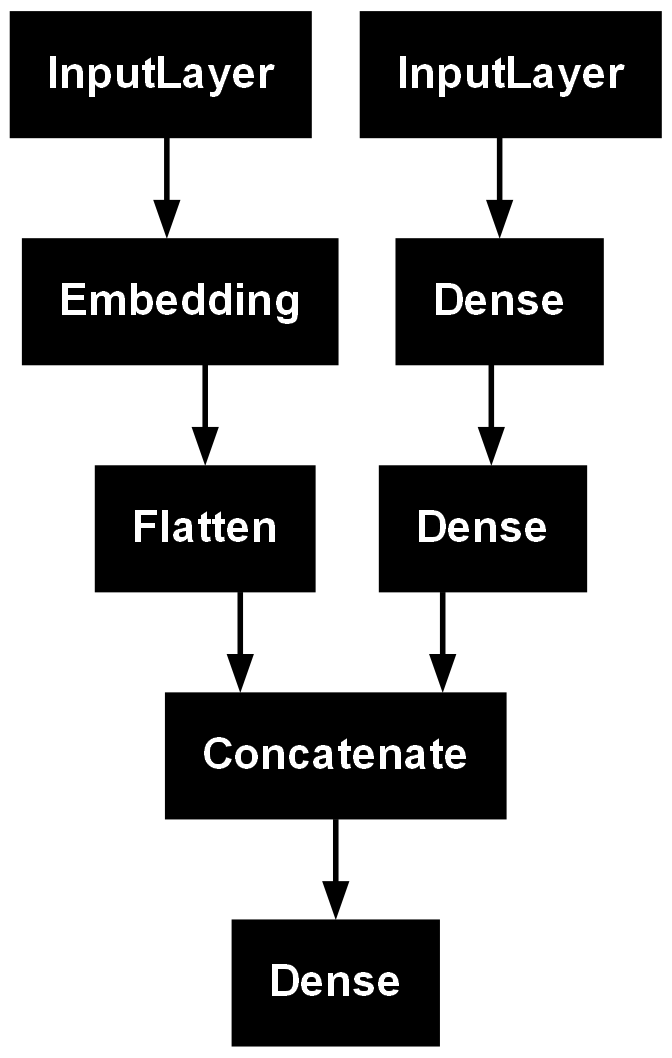

In [28]:
print(model.summary())
tf.keras.utils.plot_model(model)

### Training

In [30]:
batch_size = 32
epochs = 100

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(
    [names_train, X_train],
    y_train,
    validation_split = 0.2,
    batch_size = batch_size,
    epochs = epochs,
    callbacks = [tf.keras.callbacks.ReduceLROnPlateau()]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.4345 - loss: 1.9231 - val_accuracy: 0.4865 - val_loss: 1.8630 - learning_rate: 0.0010
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5862 - loss: 1.7251 - val_accuracy: 0.5135 - val_loss: 1.7252 - learning_rate: 0.0010
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6138 - loss: 1.5484 - val_accuracy: 0.5946 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6276 - loss: 1.3858 - val_accuracy: 0.5946 - val_loss: 1.4600 - learning_rate: 0.0010
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6276 - loss: 1.2388 - val_accuracy: 0.5946 - val_loss: 1.3414 - learning_rate: 0.0010
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6552 - loss: 1.1086 - val_accuracy: 0.6486 - val_loss: 1.2291 - learning_rate: 0.0010
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6966 - loss: 0.9864 - val_accuracy:

### Results

In [31]:
results = model.evaluate([names_test, X_test], y_test, verbose=0)

In [32]:
print("Model Accuracy:", results[1])

Model Accuracy: 0.9230769276618958
